In [2]:
import pandas as pd

hour_df = pd.read_parquet("s3://dsan6000-wikipedia/hourly_parquet/20260901_040000.parquet")
hour_df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [ ]:
import boto3

s3 =  boto3.client('s3')
df = []

paginator = s3.get_paginator('list_objects_v2')

for page in paginator.paginate(Bucket='dsan6000-ts1553', Prefix='wikipedia-hourly/'):
    for content in page.get('Contents', []):
        key = content['Key']
        if key.endswith('.parquet'):
            hourly_df = pd.read_parquet(f"s3://dsan6000-ts1553/{key}")
            df.append(hourly_df)

df = pd.concat(df, ignore_index=True)

print(f"Total rows: {len(df)}")
print(df.head())


Total rows: 119708
              datetime                        $schema  \
0  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
1  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
2  2026-09-01 04:00:01  /mediawiki/recentchange/1.0.0   
3  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
4  2026-09-01 04:00:03  /mediawiki/recentchange/1.0.0   

                                                meta            id  type  \
0  {'uri': 'https://en.wikipedia.org/wiki/Jake_O%...  2.063884e+09  edit   
1  {'uri': 'https://en.wikipedia.org/wiki/Beverid...  2.063884e+09  edit   
2  {'uri': 'https://en.wikipedia.org/wiki/1920_Un...  2.063884e+09  edit   
3  {'uri': 'https://en.wikipedia.org/wiki/1987_Ae...  2.063884e+09  edit   
4  {'uri': 'https://en.wikipedia.org/wiki/Marvin_...  2.063884e+09  edit   

   namespace                                              title  \
0          0                                     Jake O'Donnell   
1          0                                   

In [6]:
import seaborn as sns

plot_1 = sns.lineplot(data=df,x='hour',y='event counts')
plot_1.savefig('images/hourly-events.svg')
plot_1.savefig('images/hourly-events.png')

ValueError: Could not interpret value `hour` for `x`. An entry with this name does not appear in `data`.

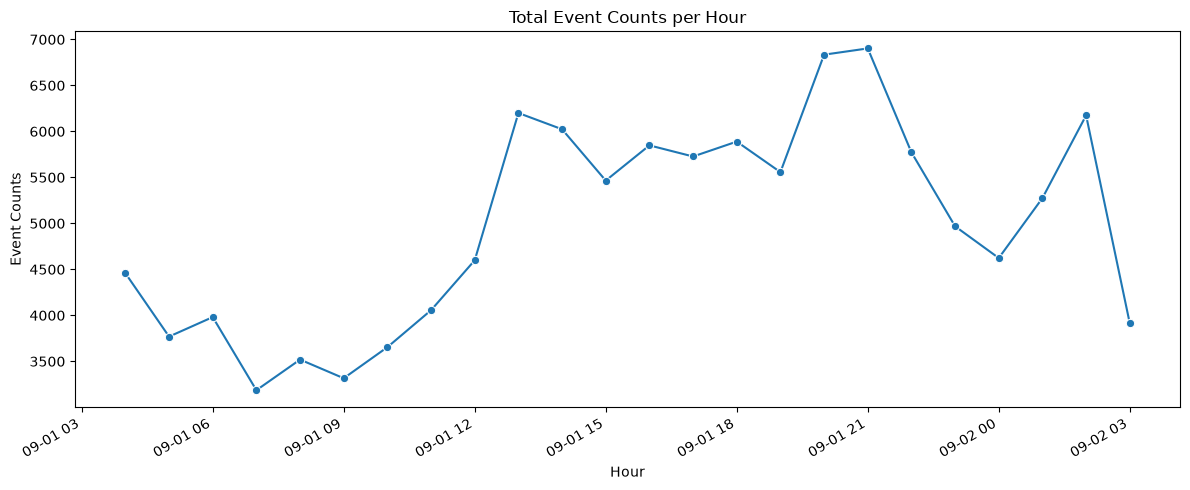

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt 

df['hour'] = pd.to_datetime(df['datetime']).dt.floor('h')

hourly_counts = (df.groupby('hour').size().reset_index(name='event counts'))

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=hourly_counts,
    x='hour',
    y='event counts',
    marker='o',
    ax=ax
)

ax.set(
    title='Total Event Counts per Hour',
    xlabel='Hour',
    ylabel='Event Counts'
)
fig.autofmt_xdate()
fig.tight_layout()

fig.savefig('images/hourly-events.svg', bbox_inches='tight')
fig.savefig('images/hourly-events.png', dpi=300, bbox_inches='tight')
plt.show()

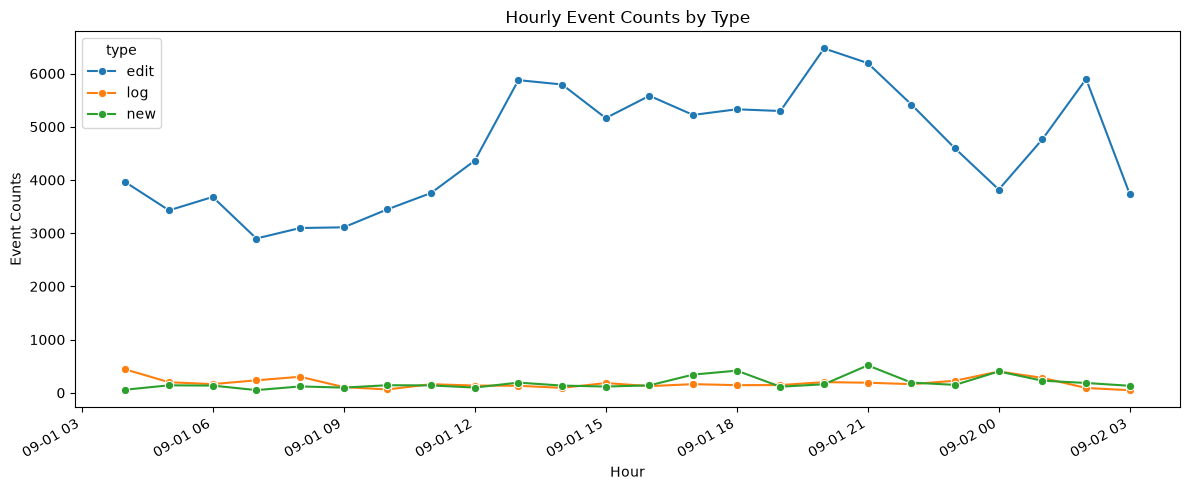

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

counts_by_type = (
    df.groupby(['hour', 'type'])
      .size()
      .unstack(fill_value=0)  
      .stack()
      .reset_index(name='event counts')
)

sns.lineplot(
    data=counts_by_type,
    x='hour',
    y='event counts',
    marker='o',
    hue = 'type',
    ax=ax
)


ax.set(
    title='Hourly Event Counts by Type',
    xlabel='Hour',
    ylabel='Event Counts'
)
fig.autofmt_xdate()
fig.tight_layout()

fig.savefig('images/events-by-type.svg', bbox_inches='tight')
fig.savefig('images/events-by-type.png', dpi=300, bbox_inches='tight')
plt.show()